In [1]:
# ==========================================================
# INSTALL REQUIRED LIBRARIES
# ==========================================================

!pip -q install tensorflow
!pip -q install opencv-python
!pip -q install scikit-learn
!pip -q install pandas
!pip -q install numpy
!pip -q install matplotlib
!pip -q install seaborn
!pip -q install pillow

In [2]:
# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import os
import zipfile
import cv2
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [4]:
print("GPU Available :", tf.config.list_physical_devices("GPU"))

GPU Available : []


In [5]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [7]:
zip_path = "archive.zip"
extract_path = "/content/drive/MyDrive/Colab Notebooks/extracted_archive"

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [8]:
for root, dirs, files in os.walk(extract_path):

    print(root)

    print("Folders :", len(dirs))

    print("Files :", len(files))

    print("--------------------------------")

/content/drive/MyDrive/Colab Notebooks/extracted_archive
Folders : 1
Files : 1
--------------------------------
/content/drive/MyDrive/Colab Notebooks/extracted_archive/socal_pics
Folders : 2
Files : 0
--------------------------------
/content/drive/MyDrive/Colab Notebooks/extracted_archive/socal_pics/train
Folders : 1
Files : 0
--------------------------------
/content/drive/MyDrive/Colab Notebooks/extracted_archive/socal_pics/train/house
Folders : 0
Files : 2000
--------------------------------
/content/drive/MyDrive/Colab Notebooks/extracted_archive/socal_pics/val
Folders : 1
Files : 0
--------------------------------
/content/drive/MyDrive/Colab Notebooks/extracted_archive/socal_pics/val/house
Folders : 0
Files : 1000
--------------------------------


In [9]:
csv_path = os.path.join(
    extract_path,
    "socal2_cleaned_mod.csv"
)

df = pd.read_csv(csv_path)

In [10]:
df.head()

,image_id,n_citi,bed,bath,sqft,price
0,1,48,3,2,713,228500
1,4,55,4,3,2547,385100
2,6,55,4,3,2769,415000
3,7,48,5,2,2600,545000
4,8,48,5,2,2600,545000


In [11]:
print(df.shape)

(12518, 6)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12518 entries, 0 to 12517
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   image_id  12518 non-null  int64
 1   n_citi    12518 non-null  int64
 2   bed       12518 non-null  int64
 3   bath      12518 non-null  int64
 4   sqft      12518 non-null  int64
 5   price     12518 non-null  int64
dtypes: int64(6)
memory usage: 586.9 KB


In [13]:
df.isnull().sum()

,0
image_id,0
n_citi,0
bed,0
bath,0
sqft,0
price,0


In [ ]:
df.dropna(inplace=True)

In [14]:
df.describe()

,image_id,n_citi,bed,bath,sqft,price
count,12518.000000,12518.000000,12518.000000,12518.000000,12518.000000,1.251800e+04
mean,7671.242131,216.511104,3.549369,2.423390,2177.679981,6.853688e+05
std,4525.326949,113.610683,1.019620,0.955929,1024.045854,3.652546e+05
min,1.000000,0.000000,1.000000,0.000000,352.000000,1.950000e+05
25%,3717.250000,118.000000,3.000000,2.000000,1431.000000,4.350000e+05
50%,7718.500000,225.000000,3.000000,2.000000,1949.000000,6.199000e+05
75%,11572.250000,313.000000,4.000000,3.000000,2744.750000,7.999000e+05
max,15472.000000,414.000000,12.000000,36.000000,17667.000000,2.000000e+06


In [15]:
TARGET = "price"

print(df[TARGET].describe())

count    1.251800e+04
mean     6.853688e+05
std      3.652546e+05
min      1.950000e+05
25%      4.350000e+05
50%      6.199000e+05
75%      7.999000e+05
max      2.000000e+06
Name: price, dtype: float64


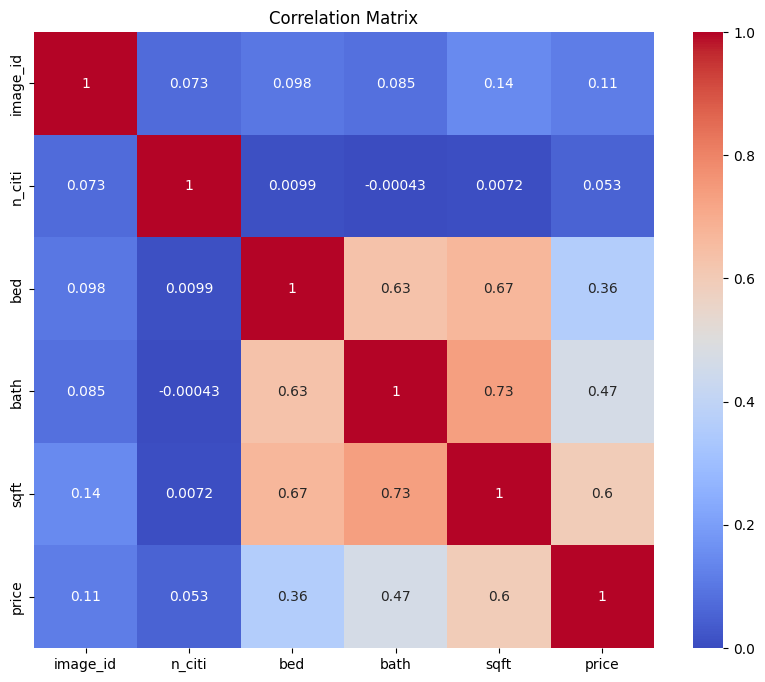

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

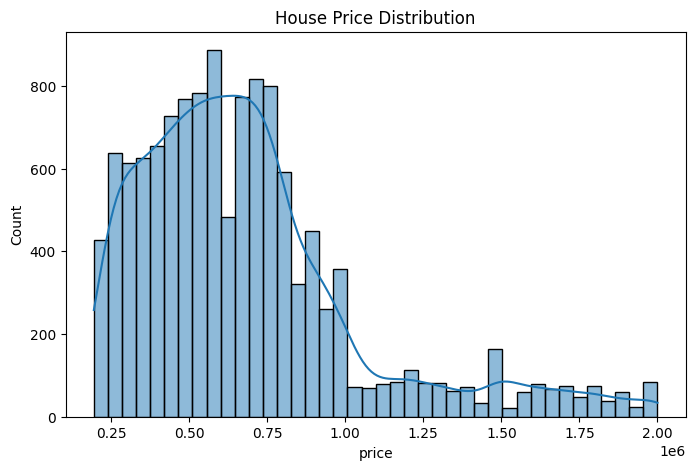

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["price"],
    bins=40,
    kde=True
)

plt.title("House Price Distribution")

plt.show()

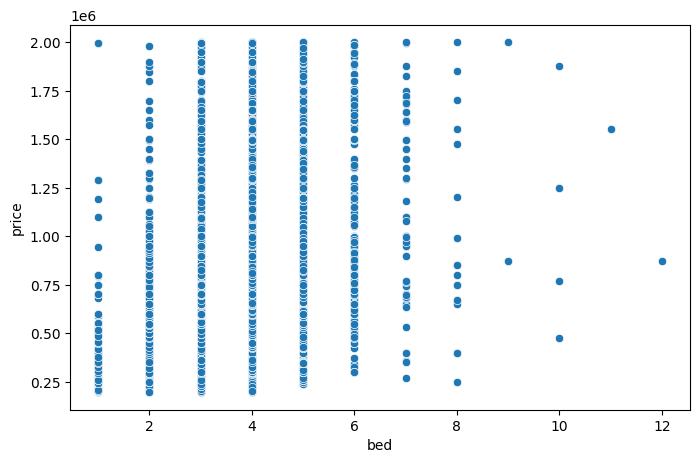

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="bed",
    y="price"
)

plt.show()

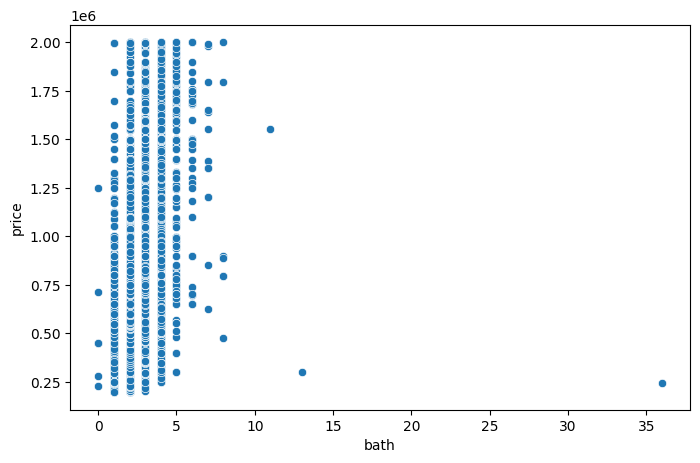

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="bath",
    y="price"
)

plt.show()

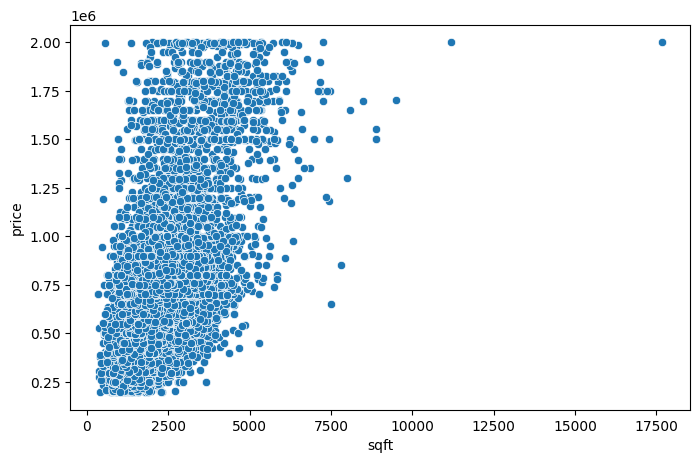

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="sqft",
    y="price"
)

plt.show()

In [21]:
IMAGE_FOLDER = os.path.join(
    extract_path,
    "socal_pics",
    "train",
    "house"
)

print(IMAGE_FOLDER)

/content/drive/MyDrive/Colab Notebooks/extracted_archive/socal_pics/train/house


In [22]:
images = os.listdir(IMAGE_FOLDER)

print("Total Images :", len(images))

Total Images : 2000


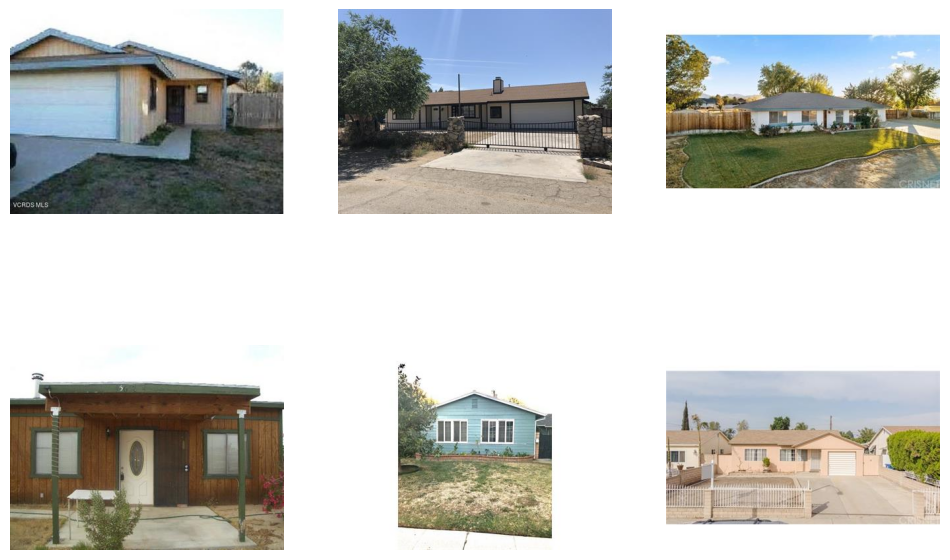

In [23]:
plt.figure(figsize=(12,8))

for i in range(6):

    img_name = random.choice(images)

    img = cv2.imread(
        os.path.join(
            IMAGE_FOLDER,
            img_name
        )
    )

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.show()

In [24]:
print(df.shape)

df.head()

(12518, 6)


,image_id,n_citi,bed,bath,sqft,price
0,1,48,3,2,713,228500
1,4,55,4,3,2547,385100
2,6,55,4,3,2769,415000
3,7,48,5,2,2600,545000
4,8,48,5,2,2600,545000


In [25]:
print(df.columns)

Index(['image_id', 'n_citi', 'bed', 'bath', 'sqft', 'price'], dtype='object')


In [26]:
df["image_id"].head(10)

,image_id
0,1
1,4
2,6
3,7
4,8
5,9
6,10
7,11
8,15
9,16


In [27]:
image_files = sorted(os.listdir(IMAGE_FOLDER))

print(image_files[:10])

['1.jpg', '10.jpg', '100.jpg', '1001.jpg', '1002.jpg', '1003.jpg', '1004.jpg', '1005.jpg', '1006.jpg', '1007.jpg']


In [28]:
IMG_SIZE = 128

In [29]:
df["image_path"] = df["image_id"].astype(str) + ".jpg"

In [33]:
df["exists"] = df["image_path"].apply(

    lambda x: os.path.exists(
        os.path.join(IMAGE_FOLDER, x)
    )

)

print(df["exists"].value_counts())

exists
False    10518
True      2000
Name: count, dtype: int64


In [34]:
df = df[df["exists"] == True]

df.reset_index(drop=True, inplace=True)

In [31]:
df.drop("exists", axis=1, inplace=True)

In [35]:
features = [

    "bed",

    "bath",

    "sqft"

]

target = "price"

In [36]:
X_tabular = df[features]

y = df[target]

In [37]:
scaler = StandardScaler()

X_tabular = scaler.fit_transform(X_tabular)

In [38]:
def load_image(path):

    img = cv2.imread(path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    img = img / 255.0

    return img

In [39]:
image_data = []

for file in df["image_path"]:

    img = load_image(

        os.path.join(
            IMAGE_FOLDER,
            file
        )

    )

    image_data.append(img)

In [40]:
image_data = np.array(image_data)

print(image_data.shape)

(2000, 128, 128, 3)


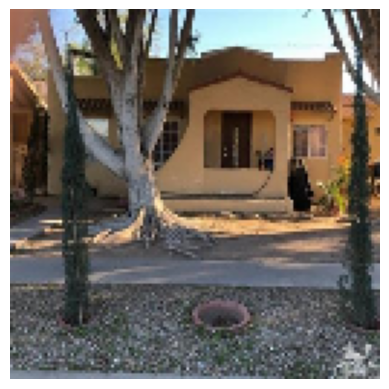

In [41]:
plt.imshow(image_data[0])

plt.axis("off")

plt.show()

In [42]:
X_train_img, X_test_img, X_train_tab, X_test_tab, y_train, y_test = train_test_split(

    image_data,

    X_tabular,

    y,

    test_size=0.2,

    random_state=42

)

In [43]:
print(X_train_img.shape)

print(X_test_img.shape)

print(X_train_tab.shape)

print(X_test_tab.shape)

(1600, 128, 128, 3)
(400, 128, 128, 3)
(1600, 3)
(400, 3)


In [44]:
print(y_train.shape)

print(y_test.shape)

(1600,)
(400,)


In [45]:
print(X_train_img.dtype)

print(X_train_tab.dtype)

float64
float64


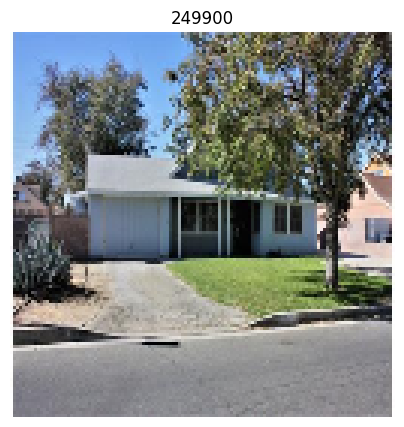

In [46]:
plt.figure(figsize=(5,5))

plt.imshow(X_train_img[10])

plt.title(y_train.iloc[10])

plt.axis("off")

plt.show()

In [47]:
from tensorflow.keras.layers import *

from tensorflow.keras.models import Model

In [48]:
# ======================================
# IMAGE INPUT
# ======================================

image_input = Input(

shape=(128,128,3)

)

In [49]:
x = Conv2D(

32,

(3,3),

activation="relu"

)(image_input)

x = MaxPooling2D()(x)

In [50]:
x = Conv2D(

64,

(3,3),

activation="relu"

)(x)

x = MaxPooling2D()(x)

In [51]:
x = Conv2D(

128,

(3,3),

activation="relu"

)(x)

x = MaxPooling2D()(x)

In [52]:
x = Flatten()(x)

In [53]:
x = Dense(

256,

activation="relu"

)(x)

x = Dropout(

0.30

)(x)

In [54]:
image_output = Dense(

128,

activation="relu"

)(x)

In [55]:
tabular_input = Input(

shape=(3,)

)

In [56]:
y = Dense(

64,

activation="relu"

)(tabular_input)

In [57]:
y = Dense(

32,

activation="relu"

)(y)

In [58]:
tabular_output = Dense(

16,

activation="relu"

)(y)

In [59]:
combined = concatenate(

[

image_output,

tabular_output

]

)

In [60]:
z = Dense(

128,

activation="relu"

)(combined)

In [61]:
z = Dropout(

0.30

)(z)

In [62]:
z = Dense(

64,

activation="relu"

)(z)

In [63]:
output = Dense(

1,

activation="linear"

)(z)

In [64]:
model = Model(

inputs=[

image_input,

tabular_input

],

outputs=output

)

In [65]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 126, 126,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 63, 63,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 61, 61,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 30, 30,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 14, 14,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 25088)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  6,422,784 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │        256 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     18,560 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 6,578,673 (25.10 MB)

 Trainable params: 6,578,673 (25.10 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.compile(

optimizer="adam",

loss="mse",

metrics=["mae"]

)

In [67]:
print("Model Ready")

Model Ready


In [68]:
# ==========================================================
# EARLY STOPPING
# ==========================================================

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [69]:
# ==========================================================
# TRAIN MODEL
# ==========================================================

history = model.fit(
    [X_train_img, X_train_tab],
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - loss: 320389775360.0000 - mae: 418185.8125 - val_loss: 133928992768.0000 - val_mae: 215592.7188
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - loss: 154955268096.0000 - mae: 260235.7500 - val_loss: 127722274816.0000 - val_mae: 237687.7969
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - loss: 154322632704.0000 - mae: 257874.0781 - val_loss: 126748418048.0000 - val_mae: 238394.7188
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - loss: 154913832960.0000 - mae: 257312.9062 - val_loss: 129197039616.0000 - val_mae: 211579.4688
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - loss: 152795414528.0000 - mae: 253941.7031 - val_loss: 136067891200.0000 - val_mae: 212471.0000
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - loss: 154729660416.0000 - mae: 254305.4062 - val_loss: 122790756352.0000 - val_mae: 233180.9219
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - loss: 151288381440.0000 - mae: 254533.7031 - val_loss: 12053

In [70]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

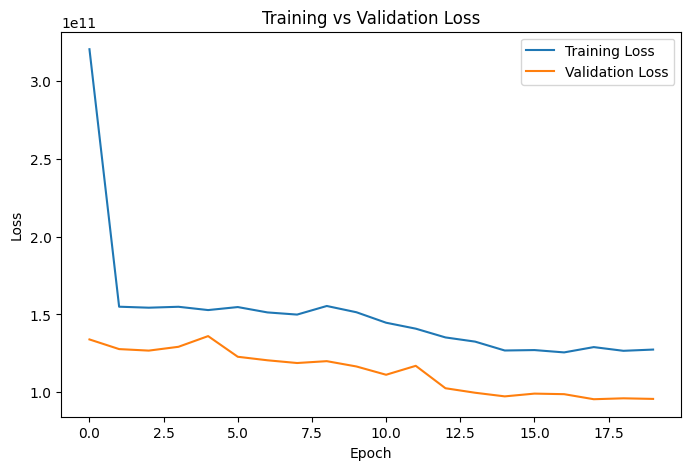

In [71]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

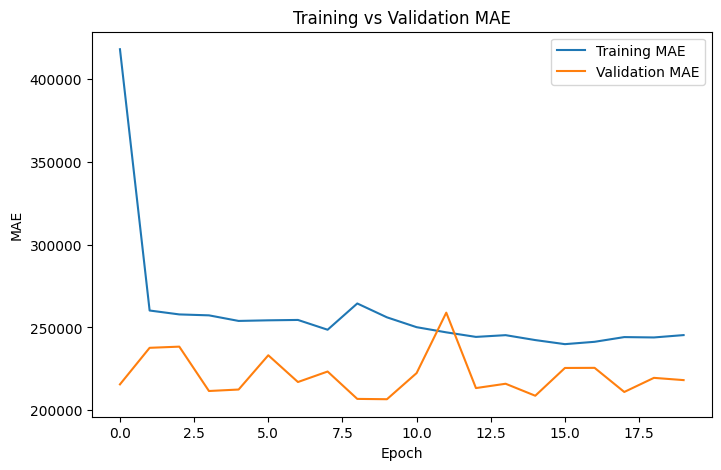

In [72]:
plt.figure(figsize=(8,5))

plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()

In [73]:
predictions = model.predict(
    [X_test_img, X_test_tab]
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 432ms/step


In [74]:
predictions = predictions.flatten()

In [75]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print("Mean Absolute Error :", mae)

Mean Absolute Error : 242381.359375


In [76]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("Root Mean Squared Error :", rmse)

Root Mean Squared Error : 384722.00922744203


In [77]:
r2 = r2_score(
    y_test,
    predictions
)

print("R2 Score :", r2)

R2 Score : 0.08196592330932617


In [78]:
results = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": predictions

})

results.head(10)

,Actual Price,Predicted Price
0,598800,442082.96875
1,999999,448628.28125
2,450000,391705.84375
3,299900,482224.56250
4,444900,637207.87500
5,449900,360435.46875
6,340000,435848.65625
7,600000,392328.00000
8,213900,405155.59375
9,440000,778365.18750


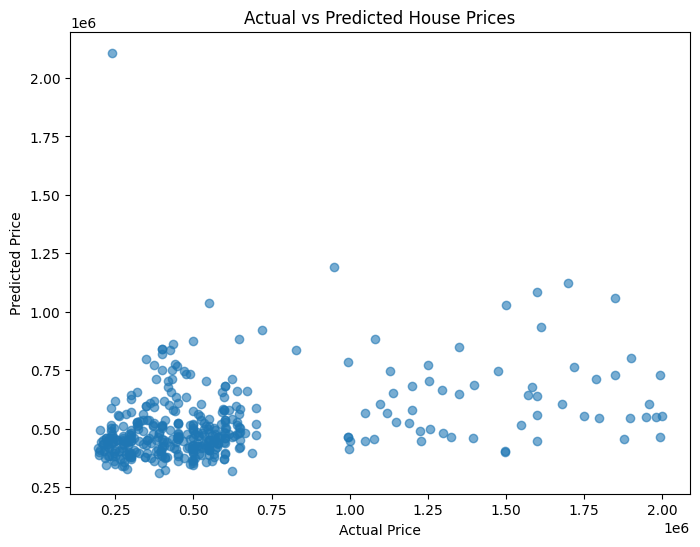

In [79]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [80]:
model.save("multimodal_house_price_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [81]:
import joblib

joblib.dump(
    scaler,
    "tabular_scaler.pkl"
)

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [82]:
from google.colab import files

files.download("multimodal_house_price_model.keras")
files.download("tabular_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [85]:
# ==========================================================
# LOAD MODEL
# ==========================================================

from tensorflow.keras.models import load_model
import joblib

model = load_model("multimodal_house_price_model.keras")
scaler = joblib.load("tabular_scaler.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [86]:
# ==========================================================
# SINGLE HOUSE PREDICTION
# ==========================================================

sample_image = X_test_img[0]
sample_tabular = X_test_tab[0].reshape(1, -1)

prediction = model.predict(
    [
        np.expand_dims(sample_image, axis=0),
        sample_tabular
    ]
)

print("Predicted Price : $", prediction[0][0])
print("Actual Price    : $", y_test.iloc[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Predicted Price : $ 442083.0
Actual Price    : $ 598800


In [87]:
# ==========================================================
# LOAD MODEL
# ==========================================================

from tensorflow.keras.models import load_model
import joblib

model = load_model("multimodal_house_price_model.keras")
scaler = joblib.load("tabular_scaler.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [88]:
# ==========================================================
# SINGLE HOUSE PREDICTION
# ==========================================================

sample_image = X_test_img[0]
sample_tabular = X_test_tab[0].reshape(1, -1)

prediction = model.predict(
    [
        np.expand_dims(sample_image, axis=0),
        sample_tabular
    ]
)

print("Predicted Price : $", prediction[0][0])
print("Actual Price    : $", y_test.iloc[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Predicted Price : $ 442083.0
Actual Price    : $ 598800


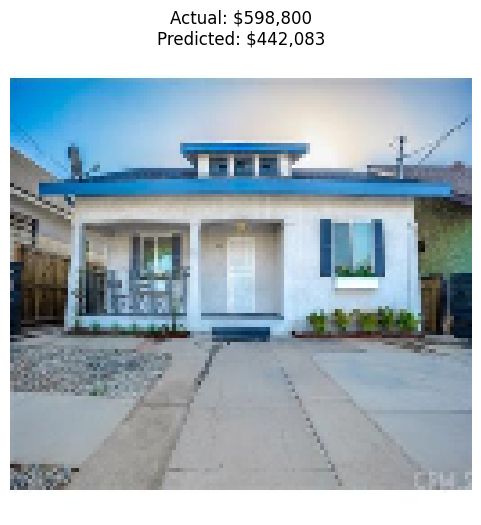

In [89]:
plt.figure(figsize=(6,6))

plt.imshow(sample_image)

plt.title(
    f"Actual: ${y_test.iloc[0]:,.0f}\nPredicted: ${prediction[0][0]:,.0f}"
)

plt.axis("off")

plt.show()

In [92]:
!pip install streamlit -q

import streamlit as st
import numpy as np
import tensorflow as tf
import joblib
from PIL import Image

model = tf.keras.models.load_model("multimodal_house_price_model.keras")
scaler = joblib.load("tabular_scaler.pkl")

st.title("🏠 Multimodal House Price Prediction")

image = st.file_uploader("Upload House Image", type=["jpg","png","jpeg"])

bed = st.number_input("Bedrooms", 1, 10, 3)
bath = st.number_input("Bathrooms", 1, 10, 2)
sqft = st.number_input("Square Feet", 500, 10000, 1500)
city = st.number_input("City Code", 1, 100, 48)

if image is not None:

    img = Image.open(image)

    img = img.resize((128,128))

    img = np.array(img)/255.0

    img = np.expand_dims(img, axis=0)

    tabular = np.array([[bed,bath,sqft,city]])

    tabular = scaler.transform(tabular)

    pred = model.predict([img,tabular])

    st.image(image)

    st.success(f"Predicted Price : ${pred[0][0]:,.2f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 79.5 MB/s eta 0:00:00


2026-07-14 04:04:39.982 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 04:04:40.138 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-14 04:04:40.139 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 04:04:40.141 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 04:04:40.142 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 04:04:40.144 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 04:04:40.145 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-14 04:04:40.147 Thread 'MainThread': mi